# 团队作业1：美国各州犯罪率与社会经济因素分析
## 大数据处理技术课程 — 2025-2026第二学期
**授课教师：周孟莹** | **数据集：Kaggle US State Crime & Socioeconomic Factors (2005-2015)**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print("Environment ready - Python + Pandas + Matplotlib + Seaborn + Scikit-learn")
print("Corresponding to: Chapter3 High-dimensional Table Data, Chapter6 Spatiotemporal Modeling")

Environment ready - Python + Pandas + Matplotlib + Seaborn + Scikit-learn
Corresponding to: Chapter3 High-dimensional Table Data, Chapter6 Spatiotemporal Modeling


In [2]:
data_dir = 'data/'
csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV files: {csv_files}")

df = pd.read_csv(os.path.join(data_dir, csv_files[0]))
print(f"\nDataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"States: {df['State'].nunique()}, Year range: {df['Year'].min()}-{df['Year'].max()}")
print(f"\nFirst 3 rows:")
display(df.head(3))

Found 1 CSV files: ['state_crime_income_merged.csv']

Dataset shape: 550 rows x 33 columns
States: 50, Year range: 2005-2015

First 3 rows:


,State,Year,Crime Count_aggravated_assault,Crime Count_burglary,Crime Count_homicide,Crime Count_larceny,Crime Count_motor_vehicle_theft,Crime Count_robbery,Crime Rate_aggravated_assault,Crime Rate_burglary,...,Black/white,GDP per capita,Gini coefficient,Hispanic/white,Labor force participation,Log of GDP per capita,"Number of corruption convictions per 1,000,000 people",People with less than 9 years of education/people with college degree or above,Poverty rate,Unemployment rate
0,Alabama,2005,11293,43473,374,120780,13140,6447,248.289096,955.801990,...,0.369125,40829.08606,0.473,0.032012,61.7,10.61715,5.68951,0.297289,13.7,4.5
1,Alabama,2006,10463,44780,382,121451,15018,7062,227.504496,973.683581,...,0.379650,40181.42086,0.472,0.035133,61.5,10.60116,11.01750,0.313032,12.6,4.0
2,Alabama,2007,11417,45379,412,124465,14238,7398,246.701979,980.563117,...,0.380464,40162.94165,0.471,0.037591,61.1,10.60070,11.12810,0.296267,13.1,4.0


### Data Dictionary

| Category | Field | Description | Course Reference |
|----------|-------|-------------|------------------|
| Spatiotemporal | State, Year | State + Year (panel data) | Chapter3: Sequence + Spatial |
| Crime Rates | Crime Rate_* | Crimes per 100k population | Continuous numerical |
| Socioeconomic | Poverty rate, Unemployment rate | Poverty %, Unemployment % | Ratio variables |
| Economic | GDP per capita, Gini coefficient | Per capita GDP, Gini | Continuous numerical |
| Education | Education ratio | Education inequality ratio | Ratio variable |
| Demographic | Population, Age, Household size | Population, median age, hh size | Discrete/Continuous |


=== Missing Value Analysis (Chapter4 pp. 9-10) ===


,Missing Count,Missing %,Data Type
Rape Revised,400,72.73,float64


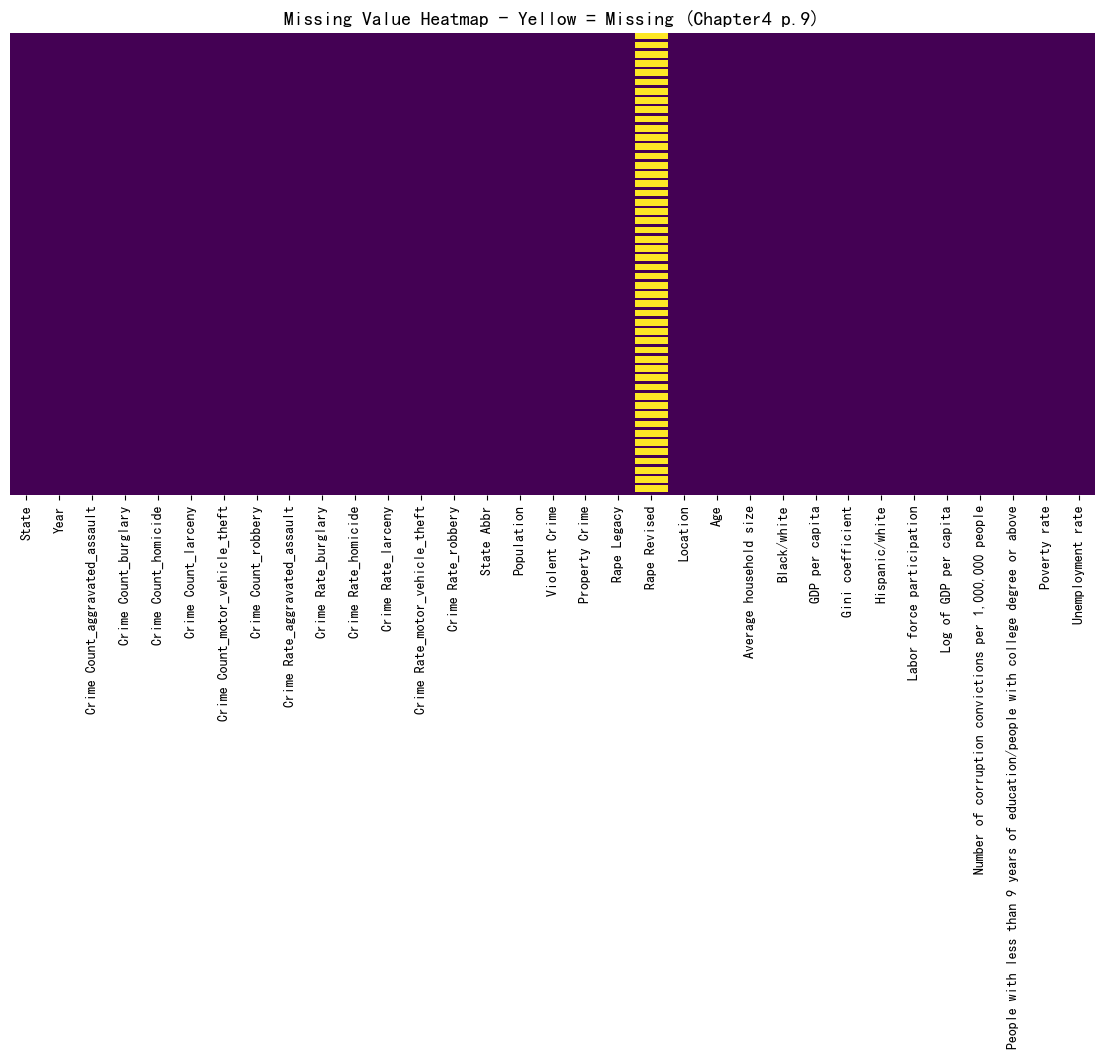

Missing value heatmap saved to output/missing_heatmap.png


In [3]:
# === Step 2: Data Cleaning ===
# Course Chapter4 "Data Preprocessing" (pp. 9-13)
# Data scientists spend 80% of time cleaning data (Chapter4 p.14)

print("=== Missing Value Analysis (Chapter4 pp. 9-10) ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2),
    'Data Type': df.dtypes.values
}).sort_values('Missing %', ascending=False)
display(missing_df[missing_df['Missing Count'] > 0])

plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap - Yellow = Missing (Chapter4 p.9)', fontsize=14)
plt.tight_layout()
plt.savefig('output/missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Missing value heatmap saved to output/missing_heatmap.png")

In [4]:
# Handle missing values (Chapter4 p.10)
# "Drop columns with >60% missing; fill numeric with median"

print("=== Handle Missing Values ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  [{col}] Filled with median {median_val:.2f} ({missing[col]} missing)")

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col].fillna(mode_val, inplace=True)
        print(f"  [{col}] Filled with mode '{mode_val}' ({missing[col]} missing)")

print(f"\nRemaining missing: {df.isnull().sum().sum()}")
assert df.isnull().sum().sum() == 0, "Still have missing values!"
print("All missing values resolved.")

=== Handle Missing Values ===
  [Rape Revised] Filled with median 1686.00 (400 missing)

Remaining missing: 0
All missing values resolved.


In [5]:
# Outlier Detection - Z-Score (Chapter4 p.11)
# "Z-Score measures how many std deviations from mean; +/-3 = outlier"

print("=== Outlier Detection: Z-Score (Chapter4 p.11) ===")

rate_cols = [c for c in df.columns if 'Crime Rate' in c]
socioeconomic_cols = ['Poverty rate', 'Unemployment rate', 'GDP per capita',
                      'Gini coefficient', 'Labor force participation']

outlier_check_cols = rate_cols + [c for c in socioeconomic_cols if c in df.columns]
outlier_data = df[outlier_check_cols].select_dtypes(include=[np.number])

z_scores = np.abs(stats.zscore(outlier_data, nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
print(f"Z-Score detected {outlier_mask.sum()} outlier rows (threshold: +/-3 sigma)")
print(f"Outlier ratio: {outlier_mask.sum() / len(df) * 100:.2f}%")

# Flag but don't drop - reserve for business judgment
df['is_outlier'] = outlier_mask

if outlier_mask.sum() > 0:
    print(f"\nOutlier rows preview:")
    display(df[outlier_mask][['State', 'Year'] + rate_cols[:3]].head(10))

=== Outlier Detection: Z-Score (Chapter4 p.11) ===
Z-Score detected 28 outlier rows (threshold: +/-3 sigma)
Outlier ratio: 5.09%

Outlier rows preview:


,State,Year,Crime Rate_aggravated_assault,Crime Rate_burglary,Crime Rate_homicide
15,Alaska,2009,463.153193,515.410044,3.149728
22,Arizona,2005,326.692040,946.210881,7.475214
23,Arizona,2006,340.284105,963.589617,8.643732
24,Arizona,2007,318.201287,946.368806,8.645231
44,California,2005,317.144808,692.924660,6.923134
45,California,2006,306.164301,678.131160,6.818890
110,Hawaii,2005,148.043082,769.038655,1.884899
188,Louisiana,2006,532.981262,1089.214715,12.943797
189,Louisiana,2007,545.536620,1093.169577,14.557892
190,Louisiana,2008,489.208751,1032.103956,12.333375


In [6]:
# Format standardization & region classification

# Standardize string columns
str_cols = df.select_dtypes(include=['object']).columns
for col in str_cols:
    df[col] = df[col].str.strip()
df['Year'] = df['Year'].astype(int)

# US 4-region classification
region_map = {
    'Northeast': ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'NJ', 'PA'],
    'Midwest': ['OH', 'IN', 'IL', 'MI', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS'],
    'South': ['DE', 'MD', 'VA', 'WV', 'KY', 'NC', 'SC', 'TN', 'GA', 'FL', 'AL', 'MS',
              'AR', 'LA', 'TX', 'OK', 'DC'],
    'West': ['MT', 'ID', 'WY', 'CO', 'NM', 'AZ', 'UT', 'NV', 'WA', 'OR', 'CA', 'AK', 'HI']
}
df['Region'] = df['State Abbr'].map(
    {abbr: r for r, states in region_map.items() for abbr in states}
)
unmapped = df[df['Region'].isna()]['State Abbr'].unique()
if len(unmapped) > 0:
    print(f"Unmapped state codes: {unmapped}")

print("Format standardization complete")
print(f"Final dataset: {df.shape}")
print(f"50 states by region:\n{df.groupby('Region')['State'].nunique()}")

Format standardization complete
Final dataset: (550, 35)
50 states by region:
Region
Midwest      12
Northeast     9
South        16
West         13
Name: State, dtype: int64


---
## Step 3: Exploratory Data Analysis (EDA)
Following Chapter3 "Getting knowledge/insights from data" paradigm (pp.4-5):
Data Construction -> Data Analysis -> Business Execution


In [7]:
# === EDA 1: Descriptive Statistics ===
print("=== Descriptive Statistics ===")
key_vars = rate_cols[:5] + ['Poverty rate', 'Unemployment rate', 'GDP per capita',
                             'Gini coefficient', 'Population']
available_key = [c for c in key_vars if c in df.columns]
display(df[available_key].describe().round(2).T)

print(f"\nData overview:")
print(f"  Total records: {len(df)}")
print(f"  States: {df['State'].nunique()}")
print(f"  Year range: {df['Year'].min()} - {df['Year'].max()}")
print(f"  Mean violent crime rate: {df['Crime Rate_aggravated_assault'].mean():.2f}/100k")
print(f"  Mean poverty rate: {df['Poverty rate'].mean():.1f}%")

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
Crime Rate_aggravated_assault,550.0,244.83,112.95,59.17,156.57,222.72,315.66,593.03
Crime Rate_burglary,550.0,641.90,232.25,223.41,452.64,592.24,818.24,1211.91
Crime Rate_homicide,550.0,4.48,2.21,0.83,2.69,4.41,5.90,14.56
Crime Rate_larceny,550.0,2033.34,420.89,1091.54,1692.40,2018.09,2353.87,3313.34
Crime Rate_motor_vehicle_theft,550.0,247.80,139.17,31.31,153.47,223.19,301.24,1116.40
Poverty rate,550.0,10.10,2.82,4.60,7.90,9.55,12.20,19.20
Unemployment rate,550.0,6.29,2.16,2.60,4.60,6.00,7.70,13.70
GDP per capita,550.0,50100.49,9700.01,33146.75,43389.17,48453.75,55450.17,80035.85
Gini coefficient,550.0,0.45,0.02,0.39,0.44,0.46,0.47,0.51
Population,550.0,6168932.09,6826372.12,508798.00,1812547.00,4373272.00,6809233.75,38993940.00



Data overview:
  Total records: 550
  States: 50
  Year range: 2005 - 2015
  Mean violent crime rate: 244.83/100k
  Mean poverty rate: 10.1%


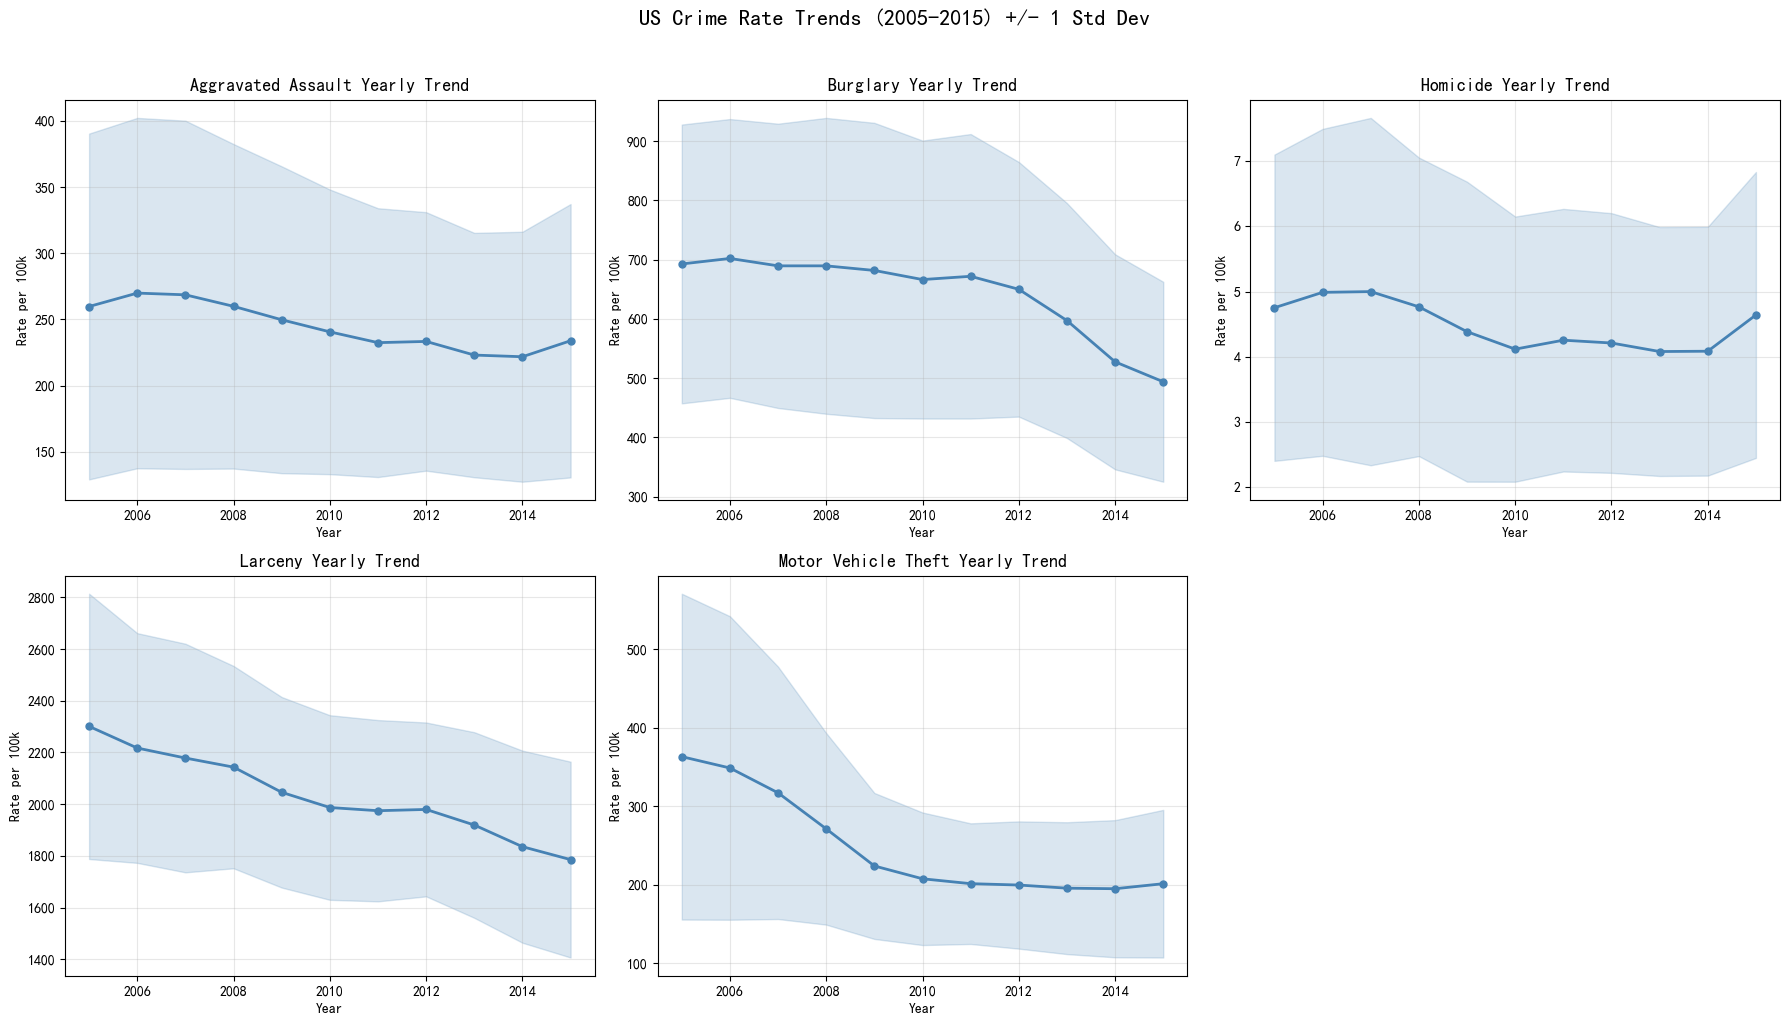

Crime rate trend chart saved to output/crime_time_trend.png

Key observation: Most crime types show a declining trend during 2005-2015


In [8]:
# === EDA 2: Crime Rate Time Trends ===
# Corresponding to "Sequence Data & Time Dimension" (Chapter3 pp.16-18)

rate_cols_labels = {
    'Crime Rate_aggravated_assault': 'Aggravated Assault',
    'Crime Rate_burglary': 'Burglary',
    'Crime Rate_homicide': 'Homicide',
    'Crime Rate_larceny': 'Larceny',
    'Crime Rate_motor_vehicle_theft': 'Motor Vehicle Theft',
    'Crime Rate_robbery': 'Robbery'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(rate_cols_labels.items()):
    ax = axes[i]
    yearly = df.groupby('Year')[col].agg(['mean', 'std'])
    ax.fill_between(yearly.index, yearly['mean'] - yearly['std'],
                    yearly['mean'] + yearly['std'], alpha=0.2, color='steelblue')
    ax.plot(yearly.index, yearly['mean'], 'o-', linewidth=2, markersize=5, color='steelblue')
    ax.set_title(f'{label} Yearly Trend', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Rate per 100k')
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[-1])
plt.suptitle('US Crime Rate Trends (2005-2015) +/- 1 Std Dev', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('output/crime_time_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Crime rate trend chart saved to output/crime_time_trend.png")
print("\nKey observation: Most crime types show a declining trend during 2005-2015")

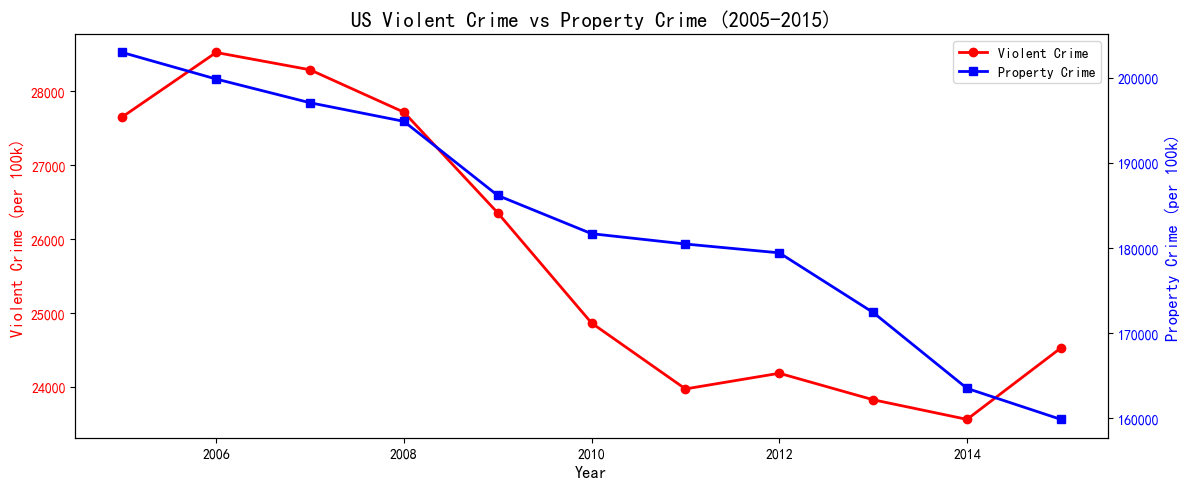

Dual-axis chart saved to output/violent_vs_property.png


In [9]:
# Violent Crime vs Property Crime trend comparison
if 'Violent Crime' in df.columns and 'Property Crime' in df.columns:
    yearly_vp = df.groupby('Year')[['Violent Crime', 'Property Crime']].mean()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    ax1.plot(yearly_vp.index, yearly_vp['Violent Crime'], 'r-o', linewidth=2, markersize=6, label='Violent Crime')
    ax2.plot(yearly_vp.index, yearly_vp['Property Crime'], 'b-s', linewidth=2, markersize=6, label='Property Crime')
    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('Violent Crime (per 100k)', color='red', fontsize=12)
    ax2.set_ylabel('Property Crime (per 100k)', color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='red')
    ax2.tick_params(axis='y', labelcolor='blue')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)
    plt.title('US Violent Crime vs Property Crime (2005-2015)', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('output/violent_vs_property.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Dual-axis chart saved to output/violent_vs_property.png")

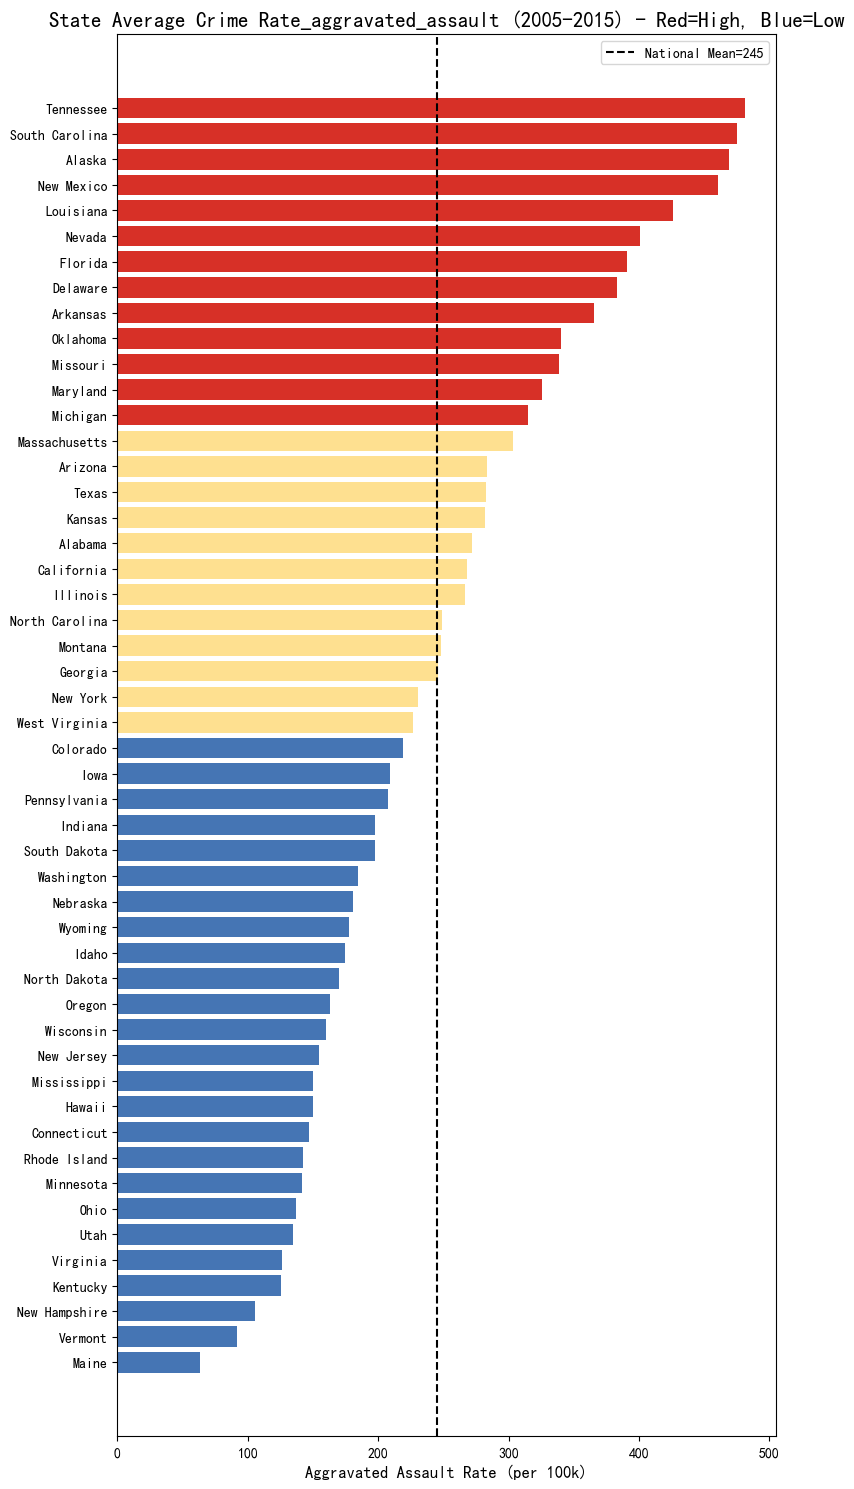

State comparison chart saved to output/state_crime_comparison.png

Top-5 high crime states: ['Louisiana', 'New Mexico', 'Alaska', 'South Carolina', 'Tennessee']
Top-5 low crime states: ['Maine', 'Vermont', 'New Hampshire', 'Kentucky', 'Virginia']


In [10]:
# === EDA 3: State Crime Comparison ===
# Corresponding to "Spatial Data" (Chapter3 pp.22-24, Chapter6)

main_crime = 'Crime Rate_aggravated_assault'
state_avg = df.groupby('State')[rate_cols].mean()
state_sorted = state_avg[main_crime].sort_values()

fig, ax = plt.subplots(figsize=(8, 15))
colors = ['#d73027' if x > state_avg[main_crime].quantile(0.75) else
          '#fee090' if x > state_avg[main_crime].median() else '#4575b4'
          for x in state_sorted.values]
ax.barh(state_sorted.index, state_sorted.values, color=colors)
ax.set_xlabel('Aggravated Assault Rate (per 100k)', fontsize=12)
ax.set_title(f'State Average {main_crime} (2005-2015) - Red=High, Blue=Low', fontsize=15, fontweight='bold')
ax.axvline(x=state_avg[main_crime].mean(), color='black', linewidth=1.5,
           linestyle='--', label=f'National Mean={state_avg[main_crime].mean():.0f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output/state_crime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("State comparison chart saved to output/state_crime_comparison.png")

print(f"\nTop-5 high crime states: {list(state_sorted.tail(5).index)}")
print(f"Top-5 low crime states: {list(state_sorted.head(5).index)}")

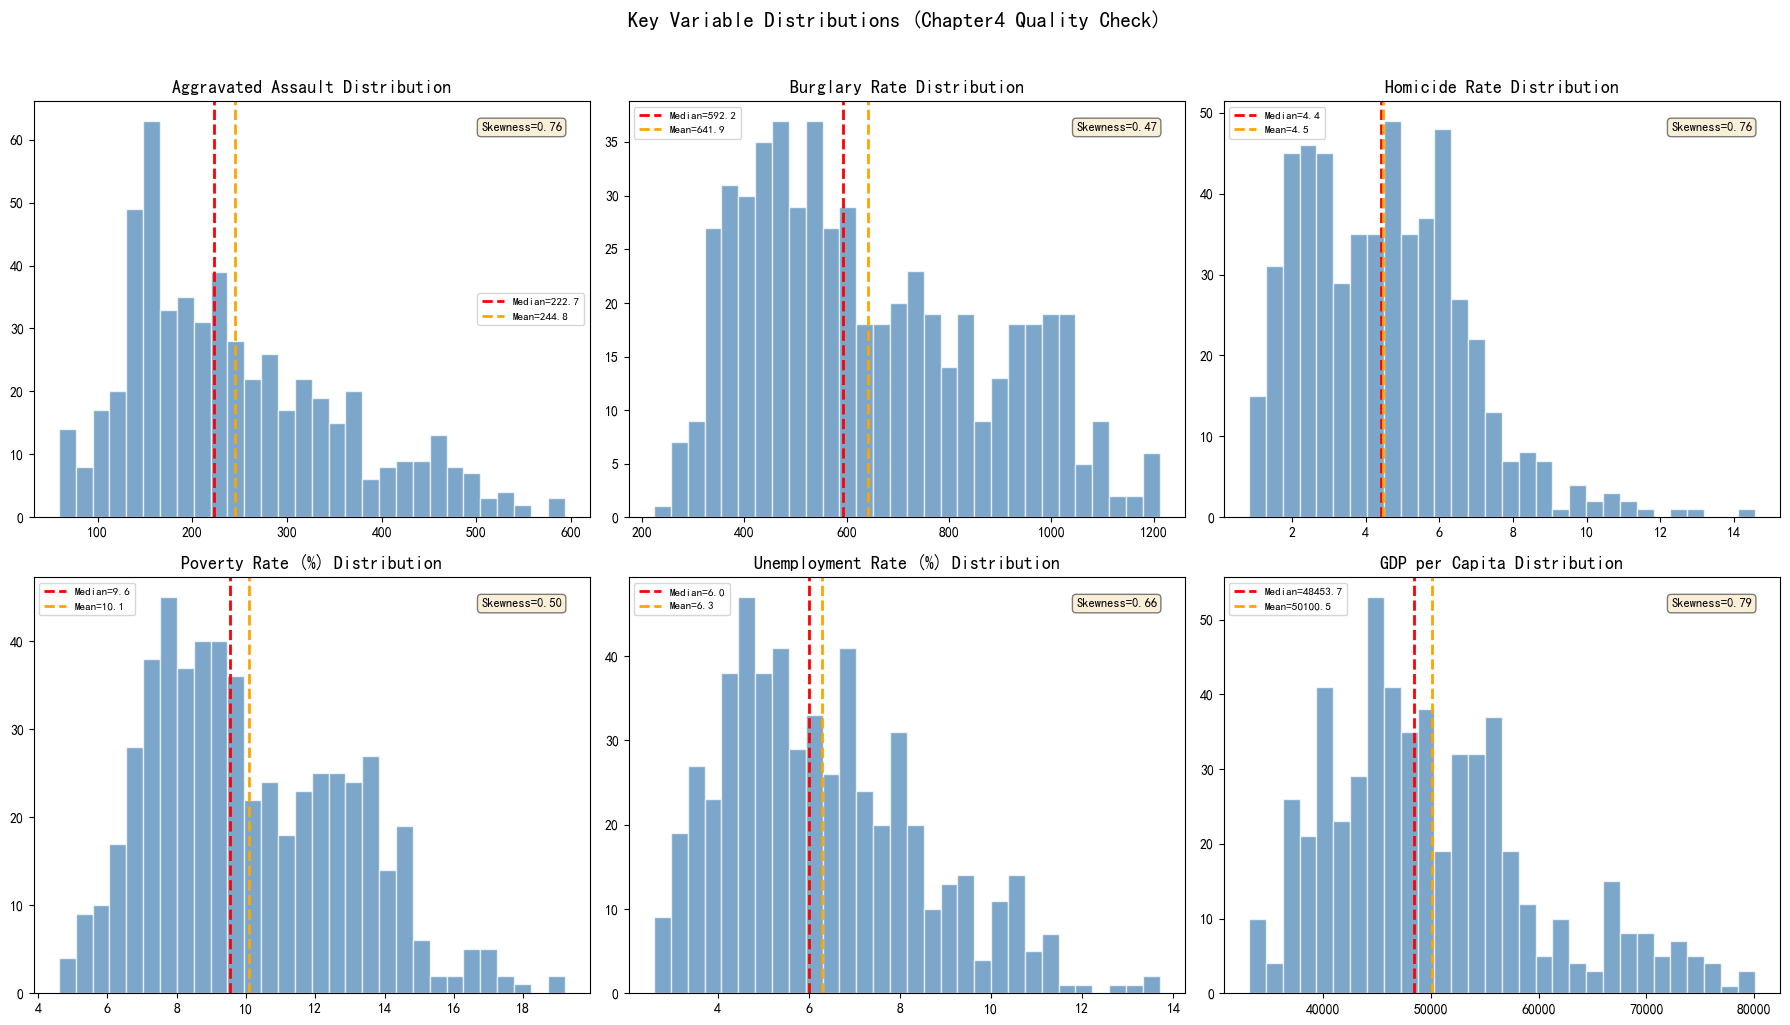

Distribution charts saved to output/variable_distributions.png


In [11]:
# === EDA 4: Key Variable Distributions ===
# Histogram + boxplot to assess skewness and outliers

dist_cols = rate_cols[:3] + ['Poverty rate', 'Unemployment rate', 'GDP per capita']
dist_labels = ['Aggravated Assault', 'Burglary Rate', 'Homicide Rate',
               'Poverty Rate (%)', 'Unemployment Rate (%)', 'GDP per Capita']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(dist_cols, dist_labels)):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, edgecolor='white', alpha=0.7, color='steelblue')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=2, label=f'Median={data.median():.1f}')
    ax.axvline(data.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean={data.mean():.1f}')
    ax.set_title(f'{label} Distribution', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.text(0.95, 0.95, f'Skewness={data.skew():.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Key Variable Distributions (Chapter4 Quality Check)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('output/variable_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution charts saved to output/variable_distributions.png")

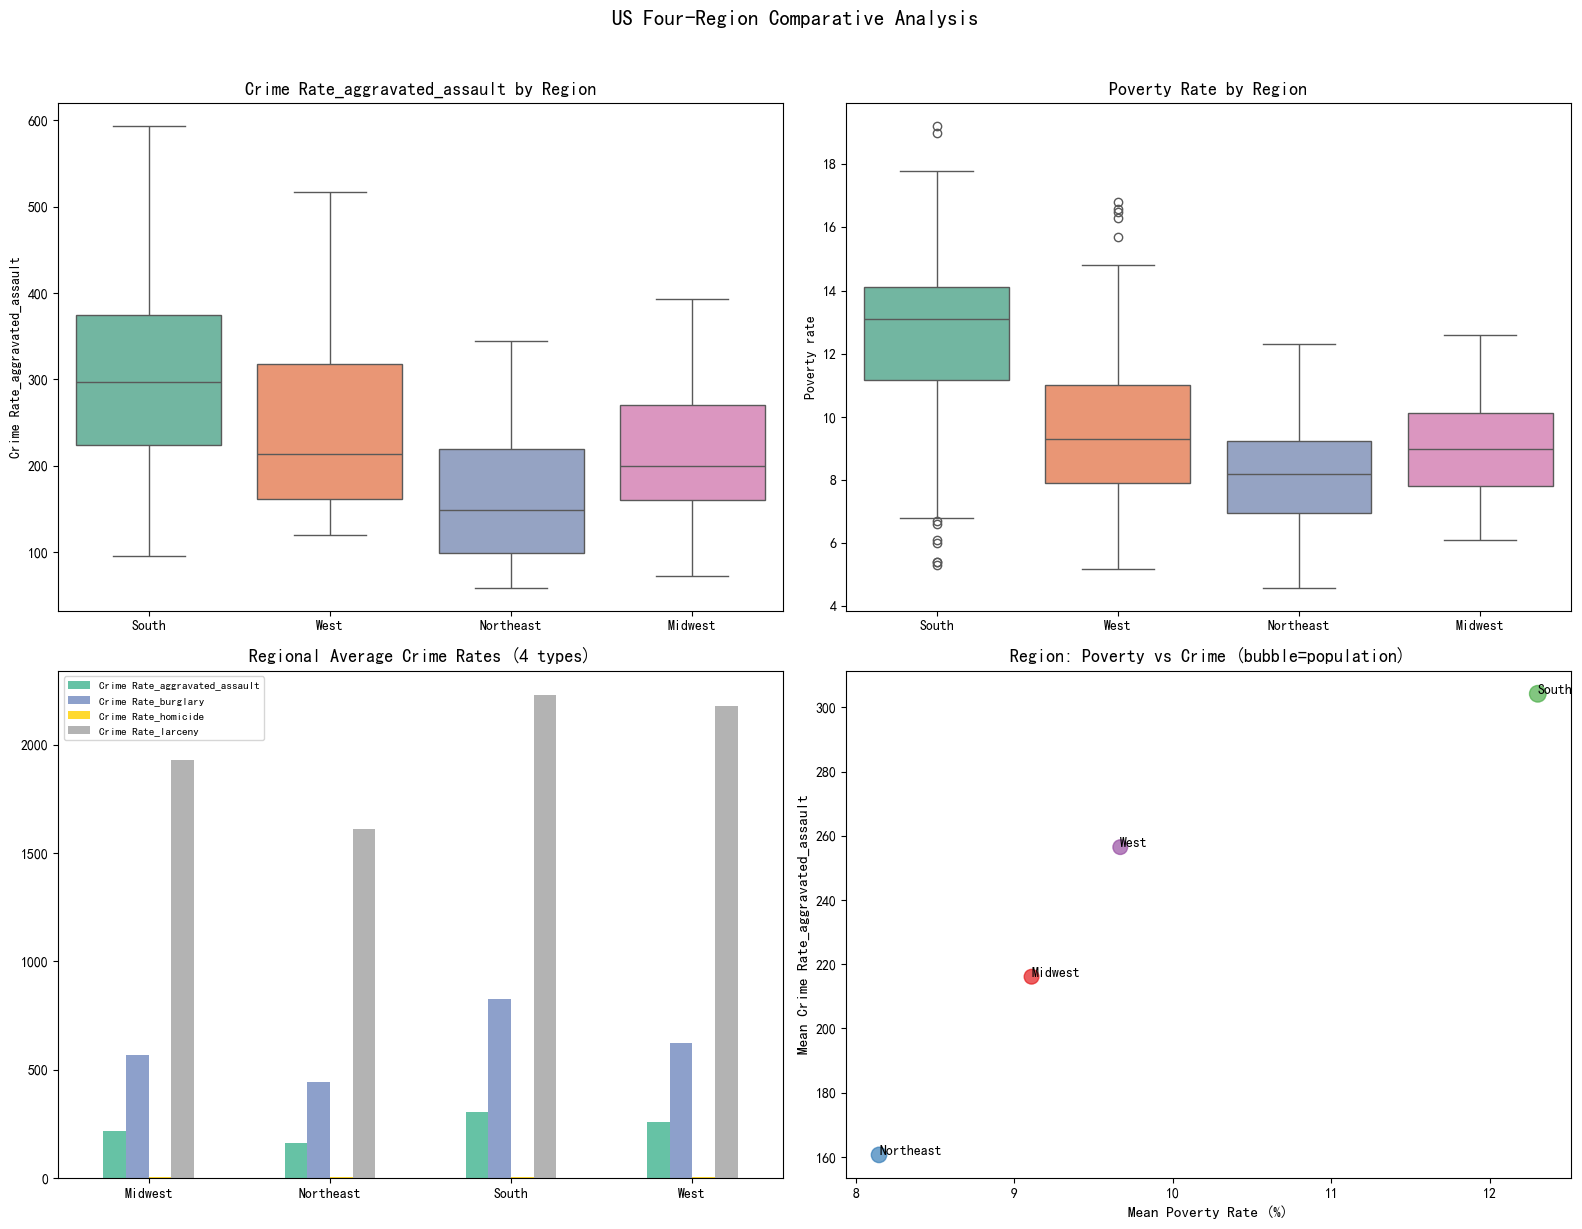

Regional comparison chart saved to output/regional_comparison.png


In [12]:
# === EDA 5: Regional Comparison ===
# Grouped by 4 US regions

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Crime rate by region
sns.boxplot(data=df, x='Region', y=main_crime, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title(f'{main_crime} by Region', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('')

# Poverty rate by region
sns.boxplot(data=df, x='Region', y='Poverty rate', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Poverty Rate by Region', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('')

# Regional average crime comparison (bar chart)
region_crime = df.groupby('Region')[list(rate_cols_labels.keys())[:4]].mean()
region_crime.plot(kind='bar', ax=axes[1, 0], colormap='Set2')
axes[1, 0].set_title('Regional Average Crime Rates (4 types)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(fontsize=8)

# Scatter: Poverty vs Crime by region
axes[1, 1].scatter(df.groupby('Region')['Poverty rate'].mean(),
                   df.groupby('Region')[main_crime].mean(),
                   s=df.groupby('Region')['Population'].mean() / 50000,
                   alpha=0.7, c=['#e41a1c', '#377eb8', '#4daf4a', '#984ea3'])
for region in df['Region'].dropna().unique():
    rd = df[df['Region'] == region]
    axes[1, 1].annotate(region, (rd['Poverty rate'].mean(), rd[main_crime].mean()),
                        fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel('Mean Poverty Rate (%)', fontsize=11)
axes[1, 1].set_ylabel(f'Mean {main_crime}', fontsize=11)
axes[1, 1].set_title('Region: Poverty vs Crime (bubble=population)', fontsize=13, fontweight='bold')

plt.suptitle('US Four-Region Comparative Analysis', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('output/regional_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Regional comparison chart saved to output/regional_comparison.png")

---
## Step 4: Feature Engineering & Correlation Analysis
Corresponding to Chapter3 "High-dimensional Table & Feature Dimensions" (p.31)
and syllabus "composite business metrics decomposition"


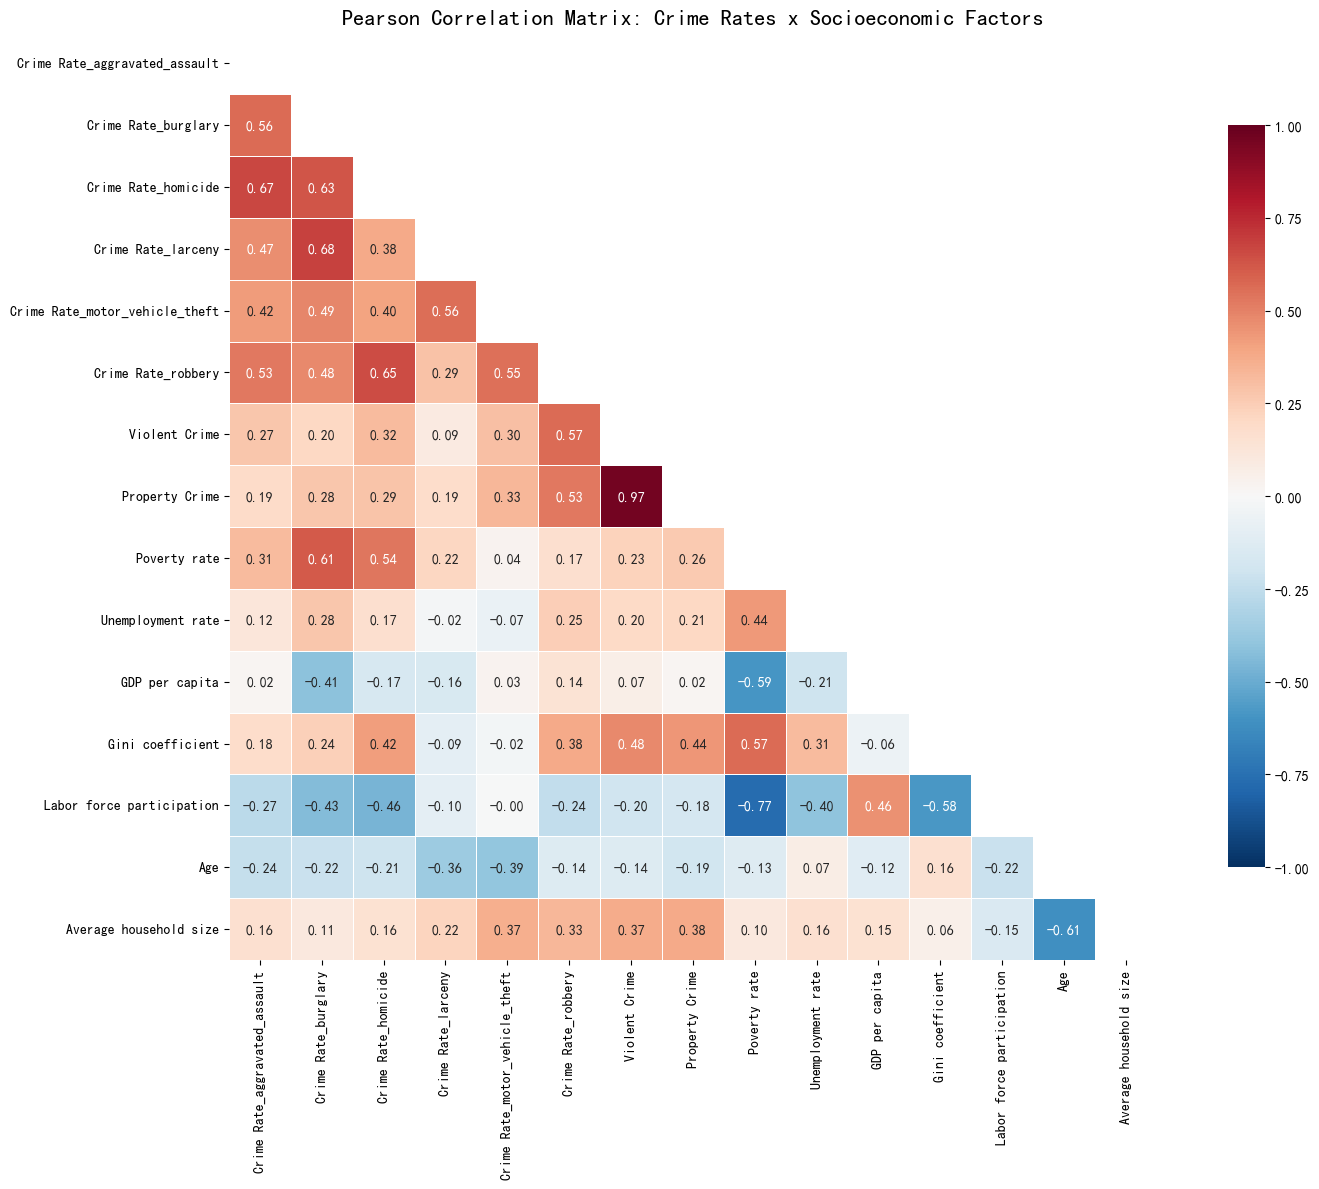

Correlation heatmap saved to output/correlation_heatmap.png


In [13]:
# === Feature Engineering 1: Pearson Correlation Matrix ===
# Chapter3 p.31 "Techniques: dimensionality reduction, clustering, feature engineering"

socio_cols = ['Poverty rate', 'Unemployment rate', 'GDP per capita',
              'Gini coefficient', 'Labor force participation', 'Age', 'Average household size']
# Include both crime rates and total crime counts
extra_crime = [c for c in ['Violent Crime', 'Property Crime'] if c in df.columns]
corr_cols_df = df[rate_cols + extra_crime + [c for c in socio_cols if c in df.columns]]
corr_matrix = corr_cols_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix: Crime Rates x Socioeconomic Factors', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved to output/correlation_heatmap.png")

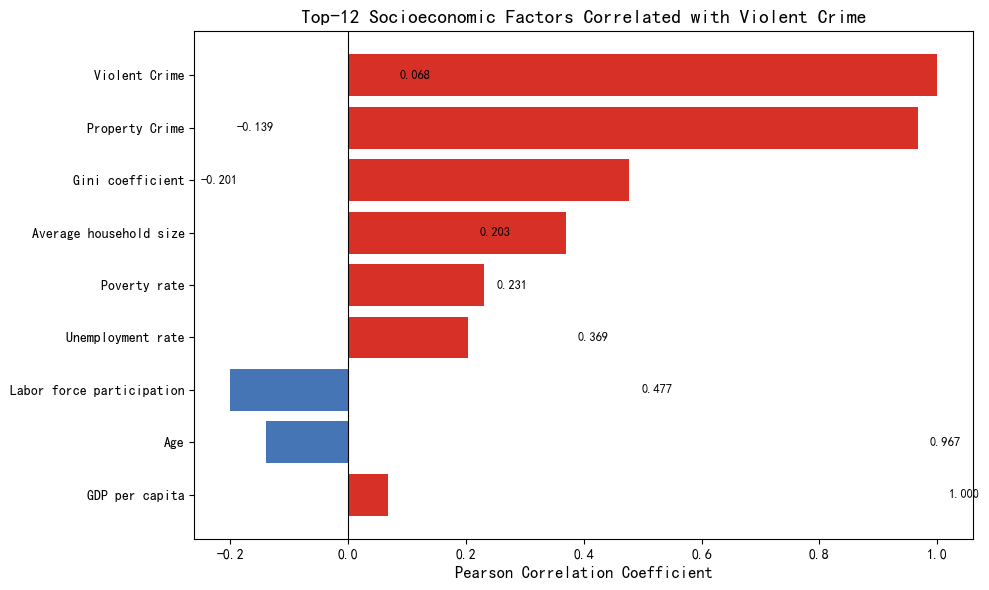

Top correlations chart saved to output/top_correlations.png

Top factors correlated with violent crime:
  Violent Crime: r = 1.000 (Positive (+))
  Property Crime: r = 0.967 (Positive (+))
  Gini coefficient: r = 0.477 (Positive (+))
  Average household size: r = 0.369 (Positive (+))
  Poverty rate: r = 0.231 (Positive (+))
  Unemployment rate: r = 0.203 (Positive (+))
  Labor force participation: r = -0.201 (Negative (-))
  Age: r = -0.139 (Negative (-))
  GDP per capita: r = 0.068 (Positive (+))


In [14]:
# Top socioeconomic factors correlated with Violent Crime
if 'Violent Crime' in corr_matrix.columns:
    target = 'Violent Crime'
else:
    target = rate_cols[0]

correlations = corr_matrix[target].drop(rate_cols, errors='ignore').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_n = 12
colors_bar = ['#d73027' if v > 0 else '#4575b4' for v in correlations.head(top_n).values]
ax.barh(correlations.head(top_n).index.tolist()[::-1],
        correlations.head(top_n).values.tolist()[::-1], color=colors_bar[::-1])
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
ax.set_title(f'Top-{top_n} Socioeconomic Factors Correlated with {target}', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

for i, (var, corr) in enumerate(correlations.head(top_n).items()):
    ax.text(corr + (0.02 if corr > 0 else -0.05), i, f'{corr:.3f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/top_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top correlations chart saved to output/top_correlations.png")

print(f"\nTop factors correlated with violent crime:")
for var, corr in correlations.head(10).items():
    direction = "Positive (+)" if corr > 0 else "Negative (-)"
    print(f"  {var}: r = {corr:.3f} ({direction})")

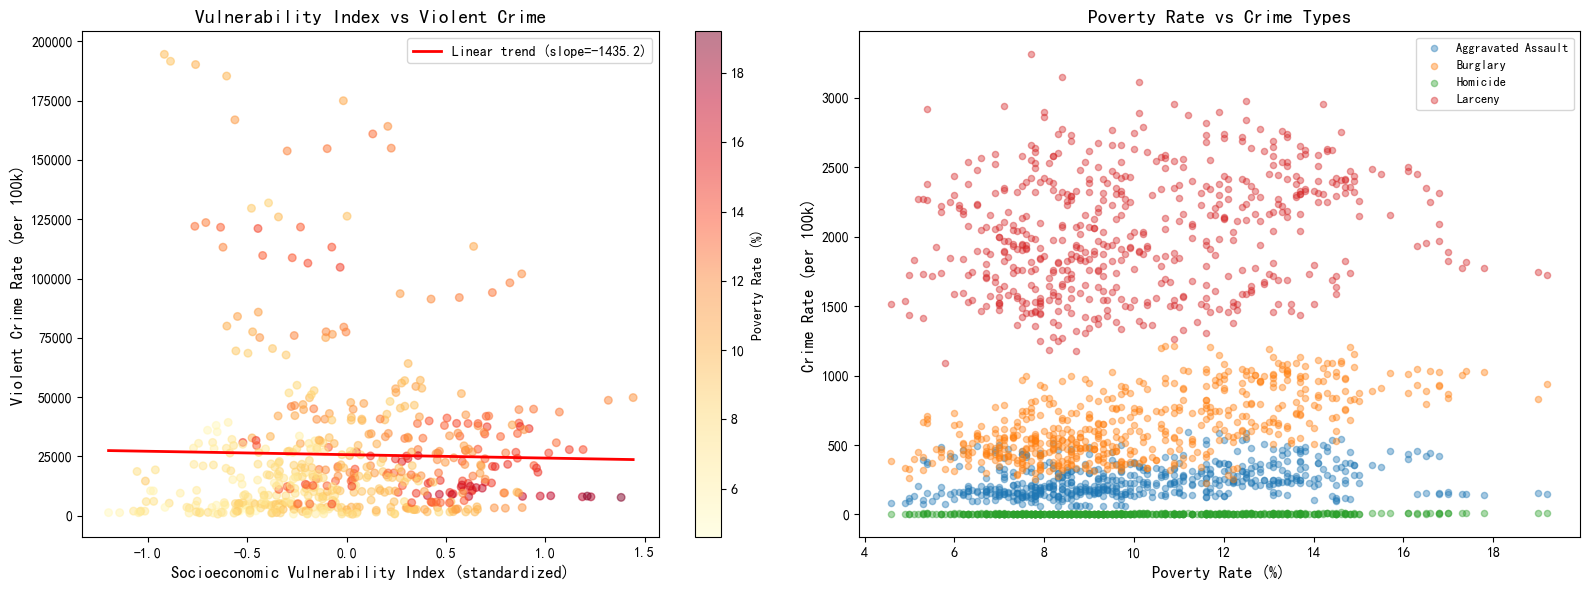

Vulnerability analysis chart saved to output/vulnerability_vs_crime.png


In [15]:
# === Feature Engineering 2: Socioeconomic Vulnerability Index ===
# Composite metric - syllabus "composite business metrics decomposition"

# Build vulnerability index: high poverty + high unemployment + low income
df['Log GDP per capita'] = np.log(df['GDP per capita'])
df['Income_neg'] = -df['Log GDP per capita']

vuln_features = [c for c in ['Poverty rate', 'Unemployment rate', 'Income_neg'] if c in df.columns]
# Education inequality (higher is worse, negative contribution)
edu_col = [c for c in df.columns if 'education' in c.lower()]
if edu_col:
    df['Edu_neg'] = -df[edu_col[0]]
    vuln_features.append('Edu_neg')

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[vuln_features].fillna(0))
df['Vulnerability_Index'] = scaled_features.mean(axis=1)

# Vulnerability Index vs Violent Crime
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if 'Violent Crime' in df.columns:
    sc = axes[0].scatter(df['Vulnerability_Index'], df['Violent Crime'],
                         c=df['Poverty rate'], cmap='YlOrRd', alpha=0.5, s=30)
    axes[0].set_xlabel('Socioeconomic Vulnerability Index (standardized)', fontsize=12)
    axes[0].set_ylabel('Violent Crime Rate (per 100k)', fontsize=12)
    axes[0].set_title('Vulnerability Index vs Violent Crime', fontsize=14, fontweight='bold')
    plt.colorbar(sc, ax=axes[0], label='Poverty Rate (%)')

    from numpy.polynomial.polynomial import polyfit
    x_vals = df['Vulnerability_Index'].dropna()
    y_vals = df['Violent Crime'].dropna()
    b, m = polyfit(x_vals, y_vals, 1)
    x_sorted = sorted(x_vals)
    axes[0].plot(x_sorted, b + m * np.array(x_sorted), 'r-', linewidth=2,
                 label=f'Linear trend (slope={m:.1f})')
    axes[0].legend()

# Poverty rate vs various crime types
for i, (col, label) in enumerate(rate_cols_labels.items()):
    if i >= 4:
        break
    axes[1].scatter(df['Poverty rate'], df[col], alpha=0.4, s=20, label=label)
axes[1].set_xlabel('Poverty Rate (%)', fontsize=12)
axes[1].set_ylabel('Crime Rate (per 100k)', fontsize=12)
axes[1].set_title('Poverty Rate vs Crime Types', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/vulnerability_vs_crime.png', dpi=150, bbox_inches='tight')
plt.show()
print("Vulnerability analysis chart saved to output/vulnerability_vs_crime.png")

=== Crime rates by poverty tertile ===


,Crime Rate_aggravated_assault,Crime Rate_burglary,Crime Rate_homicide,Crime Rate_larceny,Crime Rate_motor_vehicle_theft,Crime Rate_robbery
Poverty_Tertile,,,,,,
Low Poverty,209.9,511.1,3.3,1942.8,236.8,83.0
Mid Poverty,226.5,587.3,4.2,1999.9,258.8,95.0
High Poverty,298.7,829.7,6.0,2159.1,248.3,106.9


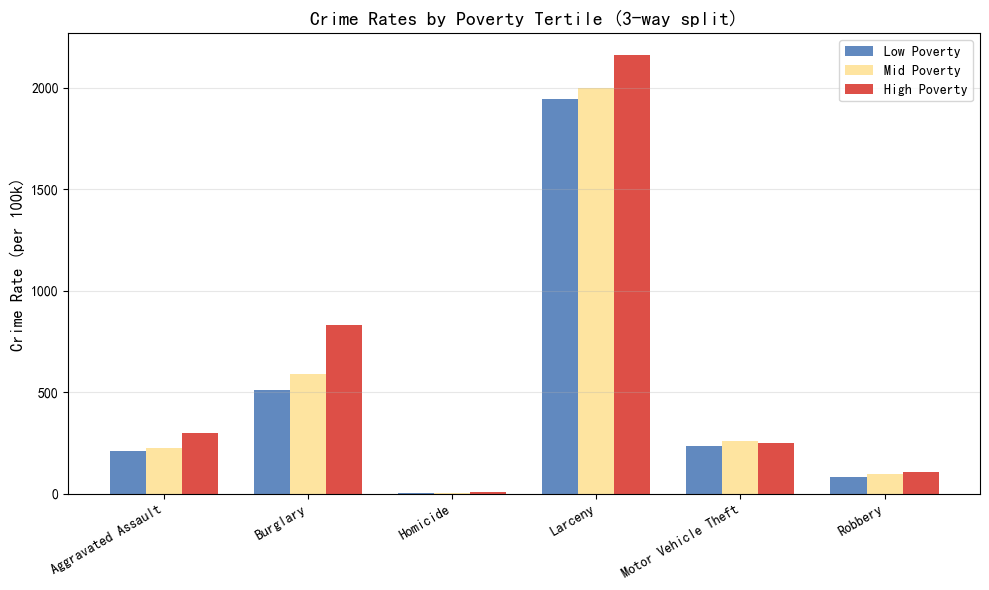

Poverty group comparison chart saved to output/poverty_group_comparison.png

High vs Low poverty crime rate differences:
  Aggravated Assault: +88.8 (+42.3%)
  Burglary: +318.6 (+62.3%)
  Homicide: +2.7 (+81.8%)
  Larceny: +216.3 (+11.1%)
  Motor Vehicle Theft: +11.5 (+4.9%)
  Robbery: +23.9 (+28.8%)


In [16]:
# === Feature Engineering 3: Poverty Tertile Analysis ===
# Group by poverty level to examine crime rate differences

df['Poverty_Tertile'] = pd.qcut(df['Poverty rate'], 3, labels=['Low Poverty', 'Mid Poverty', 'High Poverty'])
poverty_group_stats = df.groupby('Poverty_Tertile', observed=True)[list(rate_cols_labels.keys())].mean().round(1)

print("=== Crime rates by poverty tertile ===")
display(poverty_group_stats)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(rate_cols_labels))
width = 0.25

for i, (label, color) in enumerate(zip(
    ['Low Poverty', 'Mid Poverty', 'High Poverty'],
    ['#4575b4', '#fee090', '#d73027']
)):
    vals = [poverty_group_stats.loc[label, col] for col in rate_cols_labels.keys()]
    ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(rate_cols_labels.values(), rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Crime Rate (per 100k)', fontsize=12)
ax.set_title('Crime Rates by Poverty Tertile (3-way split)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/poverty_group_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Poverty group comparison chart saved to output/poverty_group_comparison.png")

# High vs Low poverty difference
print(f"\nHigh vs Low poverty crime rate differences:")
for col in rate_cols_labels.keys():
    diff = poverty_group_stats.loc['High Poverty', col] - poverty_group_stats.loc['Low Poverty', col]
    pct = diff / poverty_group_stats.loc['Low Poverty', col] * 100
    print(f"  {rate_cols_labels[col]}: +{diff:.1f} ({pct:+.1f}%)")

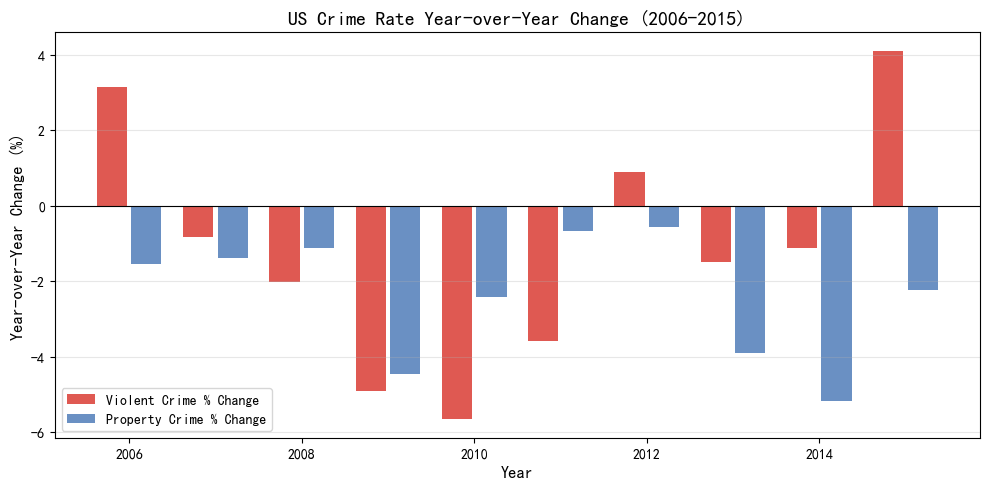

Yearly change chart saved to output/yearly_change.png


In [17]:
# === Feature Engineering 4: Year-over-Year Change ===
# Detect trend inflection points (Chapter4 "structural breakpoints")

if 'Violent Crime' in df.columns and 'Property Crime' in df.columns:
    yearly_change = df.groupby('Year')[['Violent Crime', 'Property Crime']].mean().pct_change() * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(yearly_change.index - 0.2, yearly_change['Violent Crime'], 0.35,
           color='#d73027', alpha=0.8, label='Violent Crime % Change')
    ax.bar(yearly_change.index + 0.2, yearly_change['Property Crime'], 0.35,
           color='#4575b4', alpha=0.8, label='Property Crime % Change')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Year-over-Year Change (%)', fontsize=12)
    ax.set_title('US Crime Rate Year-over-Year Change (2006-2015)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('output/yearly_change.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Yearly change chart saved to output/yearly_change.png")

---
## Step 5: Key Findings
Corresponding to syllabus "Research Capability" Goal 2:
"Statistical processing of experimental results to derive business-value engineering conclusions"


In [18]:
# === Key Findings ===
print("=" * 70)
print("  Key Findings - US Crime Rate & Socioeconomic Factors (2005-2015)")
print("  Big Data Processing Techniques - Team Assignment 1")
print("=" * 70)

# Finding 1: Strongest correlates
print(f"\n[Finding 1] Strongest socioeconomic correlates of Violent Crime:")
top5 = correlations.head(5)
for var, corr in top5.items():
    direction = "Positive" if corr > 0 else "Negative"
    strength = "Strong" if abs(corr) > 0.6 else "Moderate" if abs(corr) > 0.4 else "Weak"
    print(f"  * {var}: {direction} correlation (r={corr:.3f}, {strength})")

# Finding 2: Time trends
print(f"\n[Finding 2] Time Trends (2005-2015):")
first_3yr = df[df['Year'].isin([2005, 2006, 2007])]
last_3yr = df[df['Year'].isin([2013, 2014, 2015])]

for cname, clabel in list(rate_cols_labels.items())[:3]:
    early = first_3yr[cname].mean()
    late = last_3yr[cname].mean()
    change_pct = (late - early) / early * 100
    trend = "decreasing" if change_pct < 0 else "increasing"
    print(f"  * {clabel}: {early:.1f} -> {late:.1f} ({change_pct:+.1f}%) {trend}")

# Finding 3: Regional disparity
print(f"\n[Finding 3] Regional Disparity:")
if 'Violent Crime' in df.columns and 'Property Crime' in df.columns:
    region_means = df.groupby('Region')[['Violent Crime', 'Property Crime']].mean()
    for crime_type in ['Violent Crime', 'Property Crime']:
        max_r = region_means[crime_type].idxmax()
        min_r = region_means[crime_type].idxmin()
        ratio = region_means[crime_type].max() / region_means[crime_type].min()
        print(f"  * {crime_type}: Highest={max_r}({region_means[crime_type].max():.0f}), "
              f"Lowest={min_r}({region_means[crime_type].min():.0f}), Ratio={ratio:.1f}x")

# Finding 4: Poverty effect
print(f"\n[Finding 4] Poverty Effect:")
high_pov = df[df['Poverty_Tertile'] == 'High Poverty']['Violent Crime'].mean()
low_pov = df[df['Poverty_Tertile'] == 'Low Poverty']['Violent Crime'].mean()
print(f"  * High poverty group violent crime: {high_pov:.0f}/100k")
print(f"  * Low poverty group violent crime: {low_pov:.0f}/100k")
print(f"  * Ratio: {high_pov / low_pov:.1f}x")

# Finding 5: Education effect
edu = [c for c in df.columns if 'education' in c.lower()]
if edu and 'Violent Crime' in corr_matrix.columns:
    edu_corr = corr_matrix.loc['Violent Crime', edu[0]] if edu[0] in corr_matrix.index else np.nan
    print(f"\n[Finding 5] Education Inequality & Crime: r = {edu_corr:.3f}")

print(f"\n{'=' * 70}")
print("[Assignment 2 Directions]")
print("  * K-Means clustering for crime profiling (Chapter3 clustering)")
print("  * PCA for crime factor dimensionality reduction (Chapter3 PCA)")
print("  * Panel data regression (fixed effects) for causal estimation")
print("  * Spatial autocorrelation analysis (Moran's I) (Chapter6 spatiotemporal)")
print(f"{'=' * 70}")

  Key Findings - US Crime Rate & Socioeconomic Factors (2005-2015)
  Big Data Processing Techniques - Team Assignment 1

[Finding 1] Strongest socioeconomic correlates of Violent Crime:
  * Violent Crime: Positive correlation (r=1.000, Strong)
  * Property Crime: Positive correlation (r=0.967, Strong)
  * Gini coefficient: Positive correlation (r=0.477, Moderate)
  * Average household size: Positive correlation (r=0.369, Weak)
  * Poverty rate: Positive correlation (r=0.231, Weak)

[Finding 2] Time Trends (2005-2015):
  * Aggravated Assault: 266.1 -> 226.3 (-15.0%) decreasing
  * Burglary: 694.6 -> 539.4 (-22.4%) decreasing
  * Homicide: 4.9 -> 4.3 (-13.1%) decreasing

[Finding 3] Regional Disparity:
  * Violent Crime: Highest=South(33351), Lowest=Midwest(21166), Ratio=1.6x
  * Property Crime: Highest=South(242936), Lowest=Northeast(128427), Ratio=1.9x

[Finding 4] Poverty Effect:
  * High poverty group violent crime: 35337/100k
  * Low poverty group violent crime: 11858/100k
  * Ratio

In [19]:
# === Final: Data Pipeline Summary ===
print("=== Data Pipeline Summary ===")
print(f"Raw data: 550 rows x 33 columns")
print(f"Cleaned: {len(df)} rows x {len(df.columns)} cols (+{len(df.columns)-33} derived columns)")
print(f"Missing values: 0 (all resolved)")
print(f"Outlier flags: {df['is_outlier'].sum()} rows (flagged, not dropped)")
print(f"Visualizations: 9 charts saved to output/")
print(f"\nDerived features:")
print(f"  * Region -- 4-region classification")
print(f"  * Poverty_Tertile -- poverty 3-way split")
print(f"  * Vulnerability_Index -- socioeconomic vulnerability index")
print(f"  * Log GDP per capita -- GDP log transformation")
print(f"\nCourse knowledge coverage:")
print(f"  [OK] Chapter3: tabular data, feature engineering, high-dim features")
print(f"  [OK] Chapter4: data cleaning (Z-Score, missing values, outliers)")
print(f"  [OK] Chapter6: spatiotemporal data (geographic distribution)")
print(f"  [OK] Syllabus: multi-dim data modeling, complex problem analysis")

=== Data Pipeline Summary ===
Raw data: 550 rows x 33 columns
Cleaned: 550 rows x 40 cols (+7 derived columns)
Missing values: 0 (all resolved)
Outlier flags: 28 rows (flagged, not dropped)
Visualizations: 9 charts saved to output/

Derived features:
  * Region -- 4-region classification
  * Poverty_Tertile -- poverty 3-way split
  * Vulnerability_Index -- socioeconomic vulnerability index
  * Log GDP per capita -- GDP log transformation

Course knowledge coverage:
  [OK] Chapter3: tabular data, feature engineering, high-dim features
  [OK] Chapter4: data cleaning (Z-Score, missing values, outliers)
  [OK] Chapter6: spatiotemporal data (geographic distribution)
  [OK] Syllabus: multi-dim data modeling, complex problem analysis
